In [1]:
""" Problem 6.3.1 """

import matplotlib.pyplot as plt
import numpy as np
from math import exp, cos, sin, log
from math import pi, sqrt, exp, cos, sin
from cmath import exp
from scipy import linalg
from scipy.linalg import expm

In [2]:
""" Matrix Definitions """

dt = 0.01 # Change 'dt' between 0.01, 0.05, and 0.1
NN = int(15/dt)
TT = np.arange(0, dt*NN, dt)
time1 = np.zeros(NN)
time2 = np.zeros(NN)
time3 = np.zeros(NN)
time4 = np.zeros(NN)
nsteps = NN

A = np.matrix('0 1 0 0; -9.04 -0.4 0 0; 0 0 0 1; -1 -2 -2 -3')
B1 = np.matrix('0; 1; 0; 0')
B2 = np.matrix('0; 0; 0; 1')
C = np.matrix('0 0 1 0')
x = np.matrix('0; 0; 0; 0')
x[0] = 0
x[1] = 0
x[2] = 0
x[3] = 0

""" Forcing Functions """

f = np.zeros(NN)
g = np.zeros(NN)

for n in range(0, int(10/dt)):
    f[n] = 1
for n in range(int(10/dt), NN):
    g[n] = 0.5

""" State Space Response """

y1 = np.zeros(NN)

for i in range(nsteps):    
    time1[i] = x[0]
    time2[i] = x[1]
    time3[i] = x[2]
    time4[i] = x[3]

    x = x + dt*A*x + dt*B1*f[i] + dt*B2*g[i]

    y1[i] = (C*x)[0,0]

""" State Transition Response """

F = expm(A*dt)

Ainv = np.linalg.inv(A)
I = np.eye(4)
G1 = (F-I)*Ainv*B1
G2 = (F-I)*Ainv*B2
wtime1 = np.zeros(NN)
wtime2 = np.zeros(NN)
wtime3 = np.zeros(NN)
wtime4 = np.zeros(NN)
y2 = np.zeros(NN)

w = np.matrix('0;0;0;0')
w[0] = 0
w[1] = 0
w[2] = 0
w[3] = 0

for i in range(nsteps):
    wtime1[i] = w[0]
    wtime2[i] = w[1]
    wtime3[i] = w[2]
    wtime4[i] = w[3]

    w = F*w + G1*f[i] + G2*g[i]

    y2[i] = (C*w)[0,0]

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_2572\225056545.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  time1[i] = x[0]
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_2572\225056545.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  time2[i] = x[1]
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_2572\225056545.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  time3[i] = x[2]
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_2572\225056545.py:40: Deprecation

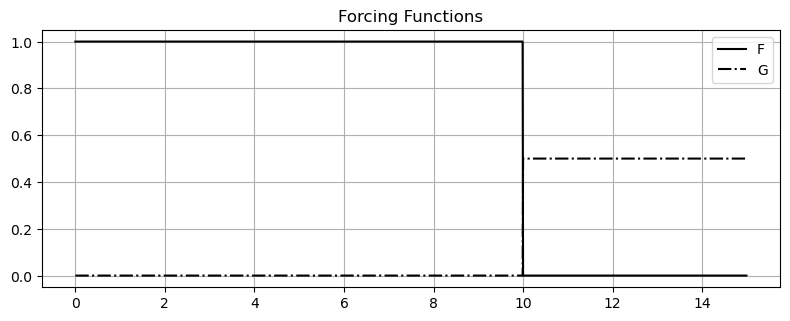

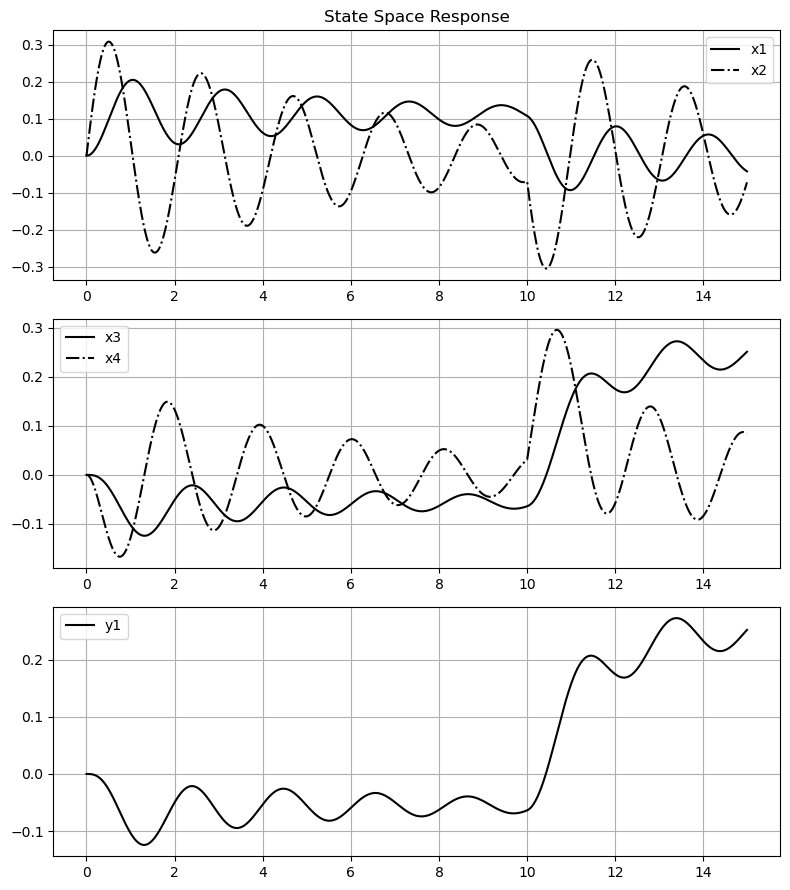

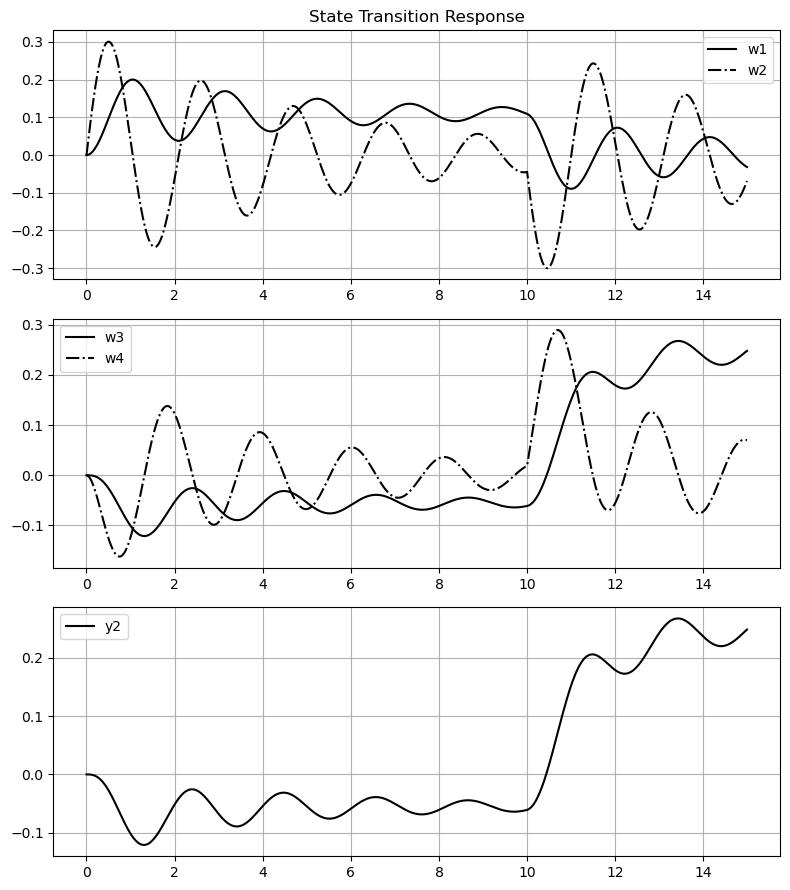

In [4]:
plt.figure(figsize = (8,9))
plt.subplot(311)
plt.title('Forcing Functions')
plt.plot(TT, f, 'k', label = 'F')
plt.plot(TT, g, 'k-.', label = 'G')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


plt.figure(figsize = (8,9))
plt.subplot(311)
plt.plot(TT, time1, 'k', label = 'x1')
plt.plot(TT, time2, 'k-.', label = 'x2')
plt.legend()
plt.grid()
plt.title('State Space Response')

plt.subplot(312)
plt.plot(TT, time3, 'k', label = 'x3')
plt.plot(TT, time4, 'k-.', label = 'x4')
plt.legend()
plt.grid()

plt.subplot(313)
plt.plot(TT, y1, 'k', label = 'y1')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


plt.figure(figsize = (8,9))
plt.subplot(311)
plt.plot(TT, wtime1, 'k', label = 'w1')
plt.plot(TT, wtime2, 'k-.', label = 'w2')
plt.legend()
plt.grid()
plt.title('State Transition Response')

plt.subplot(312)
plt.plot(TT, wtime3, 'k', label = 'w3')
plt.plot(TT, wtime4, 'k-.', label = 'w4')
plt.legend()
plt.grid()

plt.subplot(313)
plt.plot(TT, y2, 'k', label = 'y2')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()